In [31]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from cbm.data.utils import sample_mrf_prec
from cbm.estimation import estimate_bottleneck_and_mechanism_fcts
from cbm import GaussianLangevinMechanism, MacroCausalVar, SCBM

In [1]:
# 1. Define (simple, two node) model
# 2. Plot bottleneck space with some color pattern
# 3. Map points in bottleneck space back to observation space, mapping color to X points
# 4. Estimate bottleneck
# 5. Apply map form 3., visualize results to show correspondence of points and how space "warps"

In [42]:
seed = 42
rs = np.random.RandomState(seed=seed)

In [43]:
# Define two node SCBM

# Shared vars
n_micro = 4  # nr of internal nodes

M = np.ones((n_micro, n_micro))  # internal node sparsity mask
M[0,3] = M[1,2] = M[2,1] = M[3,0] = 0

# Node 1
P1 = sample_mrf_prec(dim=n_micro, M=M, rs=rs)  # precision matrix
mech1 = GaussianLangevinMechanism(mu=np.zeros(n_micro), E=np.linalg.inv(P1))

X1 = MacroCausalVar(parents=None, bottleneck_fcts=None, mechanism=mech1, d=n_micro)

# Node 2
P2 = sample_mrf_prec(dim=n_micro, M=M, rs=rs)  # precision matrix

# Sample linear bottleneck function
d_bottleneck = 2
w_bn = rs.uniform(size=(n_micro, d_bottleneck))
# Make sure rank is correct
while np.linalg.matrix_rank(w_bn) < d_bottleneck:
    w_bn = rs.uniform(size=(n_micro, d_bottleneck))

def f_bn(x):
    return x @ w_bn

# Sample linear mechanism function
w_mech = rs.uniform(size=(d_bottleneck, n_micro))
while np.linalg.matrix_rank(w_mech) < d_bottleneck:
    w_mech = rs.uniform(size=(d_bottleneck, n_micro))

def f_mech(x):
    return x @ w_mech

mech2 = GaussianLangevinMechanism(mu=f_mech, E=np.linalg.inv(P2))

X2 = MacroCausalVar(parents=[X1], bottleneck_fcts=[f_bn], mechanism=mech2, d=n_micro)

variables = np.empty(2, dtype=object)
variables[0] = X1
variables[1] = X2

A = np.asarray([[0, 1],
                [0, 0]])
d_bottleneck_matrix = np.empty_like(A, dtype=object)
d_bottleneck_matrix[0, 1] = 2

scbm = SCBM(variables=variables, A=A, d_bottleneck_matrix=d_bottleneck_matrix, seed=seed)

In [44]:
n_samples = 1000
samples, bn_samples = scbm.sample(size=n_samples)

In [29]:
def get_rgb_color(x, y):
    hue = (np.arctan2(y, x) + np.pi) / (2*np.pi)
    saturation = np.sqrt(x ** 2 + y ** 2)
    # Standardize
    saturation = saturation / np.max(saturation)
    value = np.ones_like(hue)

    colors = matplotlib.colors.hsv_to_rgb(np.stack((hue, saturation, value)).T)

    return colors

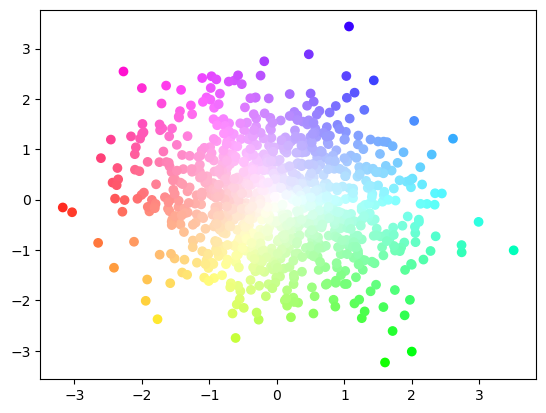

In [45]:
fig, ax = plt.subplots()

ax.scatter(bn_samples[0, 1][:, 0], bn_samples[0, 1][:, 1], c=get_rgb_color(bn_samples[0, 1][:, 0], bn_samples[0, 1][:, 1]))

plt.show()

In [46]:
# Estimate bottleneck
estimated_bn_fcts, _ = estimate_bottleneck_and_mechanism_fcts(SCBM=scbm, samples=samples, mode='linear')

In [47]:
# Apply estimated bottleneck function
estimated_bn_samples = estimated_bn_fcts[0, 1](samples[0])

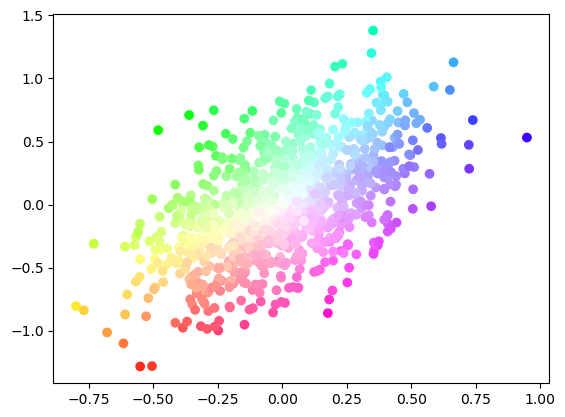

In [48]:
fig, ax = plt.subplots()

ax.scatter(estimated_bn_samples[:, 0], estimated_bn_samples[:, 1], c=get_rgb_color(bn_samples[0, 1][:, 0], bn_samples[0, 1][:, 1]))

plt.show()